In [1]:
import numpy as np
np.set_printoptions(threshold=np.inf)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import normflows as nf
import random
from torch.utils.data import DataLoader
import pandas as pd
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from scipy.stats import norm

from GPDFlow_S import S_mGPD_NF, ConditionalMaskedAffineFlow, ActNormConditional, ConditionalNormalizingFlow
import Common_Functions as cf
from matplotlib.colors import LinearSegmentedColormap
import scipy.stats as stats

from Common_Functions import empirical_tail_dependence_measure


Using device: cuda


#### Download exchange rate data from the Bank of England

In [2]:
# BoE website: https://www.bankofengland.co.uk/boeapps/database/Rates.asp?Travel=NIxASx&into=GBP
#
# Python port of the R `pdfetch::pdfetch_BOE` call used to fetch daily GBP exchange
# rates from the Bank of England Interactive Statistical Database (IADB).

import requests
from io import StringIO

# The IADB endpoint 403s on the default python-requests User-Agent, so a
# browser-like one is set explicitly.
_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/120.0 Safari/537.36"
    )
}


def pdfetch_BOE(identifiers, from_date, to_date):
    """Fetch daily series from the Bank of England IADB as a DataFrame indexed by date.

    Mirrors the R `pdfetch::pdfetch_BOE` function, which builds a CSV export URL
    against the BoE IADB `fromshowcolumns.asp` endpoint.
    """
    url = "https://www.bankofengland.co.uk/boeapps/iadb/fromshowcolumns.asp"
    params = {
        "csv.x": "yes",
        "SeriesCodes": ",".join(identifiers),
        "CSVF": "TN",
        "UsingCodes": "Y",
        "VPD": "Y",
        "Datefrom": pd.Timestamp(from_date).strftime("%d/%b/%Y"),
        "Dateto": pd.Timestamp(to_date).strftime("%d/%b/%Y"),
    }
    resp = requests.get(url, params=params, headers=_HEADERS, timeout=60)
    resp.raise_for_status()

    df = pd.read_csv(StringIO(resp.text))
    df[df.columns[0]] = pd.to_datetime(df[df.columns[0]], format="%d %b %Y")
    df = df.set_index(df.columns[0])
    df.index.name = "Date"
    return df


identifiers = [
    "XUDLADS", "XUDLCDS", "XUDLBK89", "XUDLBK25", "XUDLDKS", "XUDLERS", "XUDLHDS",
    "XUDLBK33", "XUDLBK97", "XUDLBK78", "XUDLJYS", "XUDLBK83", "XUDLNDS", "XUDLNKS",
    "XUDLBK47", "XUDLSRS", "XUDLSGS", "XUDLZRS", "XUDLBK93", "XUDLSKS",
    "XUDLSFS", "XUDLTWS", "XUDLBK87", "XUDLBK95", "XUDLUSS",
]

# RUS (XUDLBK85) excluded: the Russian rouble series stops being quoted from
# 2022-03-03 (sanctions) through the end of the sample and never resumes, which
# poisons quantile/tail-dependence computations downstream with NaNs.
ctry_codes = [
    "AUS", "CAN", "CHN", "CZE", "DNK", "EUR", "HKG", "HUN", "IND", "ISR", "JPN", "MYS",
    "NZL", "NOR", "POL", "SAU", "SGP", "ZAF", "KOR", "SWE", "CHE", "TWN", "THA",
    "TUR", "USA",
]

BoE_exchange_rates = pdfetch_BOE(identifiers, from_date="2005-10-01", to_date="2025-09-30")
BoE_exchange_rates.columns = ctry_codes

BoE_exchange_rates.to_csv("Data_and_Model/BoE_exchange_rates.csv")
BoE_exchange_rates.head()

,AUS,CAN,CHN,CZE,DNK,EUR,HKG,HUN,IND,ISR,...,SAU,SGP,ZAF,KOR,SWE,CHE,TWN,THA,TUR,USA
Date,,,,,,,,,,,,,,,,,,,,,
2005-10-03,2.3038,2.0422,14.1716,43.6484,10.9940,1.4732,13.6117,369.1584,77.2901,8.0826,...,6.5833,2.9762,11.2751,1830.9251,13.7283,2.2871,58.3229,72.2895,2.3536,1.7546
2005-10-04,2.3086,2.0650,14.2249,43.6243,11.0101,1.4753,13.6611,368.8518,77.8098,8.1082,...,6.6082,2.9838,11.3518,1836.0510,13.7293,2.2908,58.6436,72.3941,2.3759,1.7612
2005-10-05,2.3289,2.0802,14.2241,43.6776,10.9935,1.4731,13.6593,367.4519,77.8846,8.0993,...,6.6078,2.9803,11.4982,1830.6634,13.7040,2.2827,58.5310,72.2667,2.3836,1.7611
2005-10-06,2.3406,2.0989,14.3242,43.4247,10.9063,1.4617,13.7544,366.0575,78.4153,8.1375,...,6.6538,2.9834,11.5792,1848.8738,13.6244,2.2621,58.9822,72.6869,2.4040,1.7735
2005-10-07,2.3252,2.0650,14.2127,43.0673,10.8381,1.4524,13.6466,364.0819,77.9987,8.0774,...,6.6019,2.9646,11.5371,1825.6888,13.5623,2.2517,58.4766,71.9101,2.3721,1.7597


#### Preprocess exchange rates: negative log returns and GARCH-filtered residuals

In [3]:
# Negative log returns (nlr), computed column-wise, exactly as R's
# apply(data, 2, FUN = function(x) diff(log(x)))
if "BoE_exchange_rates" not in dir():
    BoE_exchange_rates = pd.read_csv(
        "Data_and_Model/BoE_exchange_rates.csv", index_col="Date", parse_dates=True
    )

data_fx = BoE_exchange_rates

nlr = pd.DataFrame(
    np.diff(np.log(data_fx.values), axis=0),
    columns=data_fx.columns,
    index=data_fx.index[1:],
)

n, d = nlr.shape
n, d


(5051, 25)

In [4]:
# ARMA(0,2)+GARCH(1,1) filtering, fit column-by-column with R's fGarch::garchFit
# via rpy2. Neither `statsmodels` nor the `arch` python package can express a pure
# MA(2) mean term (their mean models only support AR lags), and fGarch performs a
# single joint ARMA-GARCH MLE rather than a two-step fit, so we call R directly to
# match the original R code exactly.
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri, default_converter
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

fGarch = importr("fGarch")
garch_formula = ro.Formula("~arma(0,2)+garch(1,1)")


In [5]:
# Fit each column independently (mirrors the R `for(i in 1:d)` loop). RUS has a
# multi-year gap with no quoted rate (~2022 sanctions), so NAs are dropped per
# column before fitting and the standardized residuals are written back by date.
fit_fGarch = {}
residus = pd.DataFrame(np.nan, index=nlr.index, columns=nlr.columns)

for i, col in enumerate(nlr.columns):
    obs = nlr[col].dropna()

    with localconverter(default_converter + numpy2ri.converter):
        r_x = ro.conversion.py2rpy(obs.to_numpy())
        ga = fGarch.garchFit(garch_formula, data=r_x, trace=False, **{"cond.dist": "norm"})

    resid = np.asarray(ga.slots["residuals"])
    sigma_t = np.asarray(ga.slots["sigma.t"])
    residus.loc[obs.index, col] = resid / sigma_t
    fit_fGarch[col] = ga
    print(f"Done for {i + 1}/{d}")


Done for 1/25
Done for 2/25
Done for 3/25
Done for 4/25
Done for 5/25
Done for 6/25
Done for 7/25
Done for 8/25
Done for 9/25
Done for 10/25
Done for 11/25
Done for 12/25
Done for 13/25
Done for 14/25
Done for 15/25
Done for 16/25
Done for 17/25
Done for 18/25
Done for 19/25
Done for 20/25
Done for 21/25
Done for 22/25
Done for 23/25
Done for 24/25
Done for 25/25


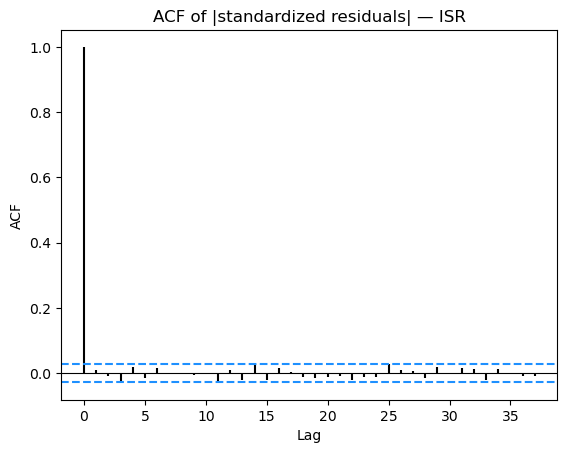

In [6]:
abs_residus = residus.abs()


def acf_plot(x, max_lag=None, ax=None):
    """Sample autocorrelation bar plot with 95% white-noise bounds, mirroring R's acf()."""
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    n_obs = len(x)
    if max_lag is None:
        max_lag = int(10 * np.log10(n_obs))
    x_c = x - x.mean()
    denom = np.sum(x_c**2)
    acf_vals = np.array(
        [1.0] + [np.sum(x_c[lag:] * x_c[:-lag]) / denom for lag in range(1, max_lag + 1)]
    )

    ax = ax or plt.gca()
    ax.vlines(np.arange(max_lag + 1), 0, acf_vals, color="black")
    ax.axhline(0, color="black", linewidth=0.8)
    bound = 1.96 / np.sqrt(n_obs)
    ax.axhline(bound, color="dodgerblue", linestyle="--")
    ax.axhline(-bound, color="dodgerblue", linestyle="--")
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")
    return acf_vals


# R's abs.residus[,10] is the 10th (1-indexed) column -> Python column index 9
acf_plot(abs_residus.iloc[:, 9])
plt.title(f"ACF of |standardized residuals| — {abs_residus.columns[9]}")
plt.show()


In [7]:
data = abs_residus
data.shape


(5051, 25)

#### Standardize margins via univariate GPD fit, then fit GPDFlow with fixed (identity) margins

The joint threshold-exceedance data used above (`samples`) is left on the raw data
scale, and GPDFlow estimates its own marginal `sigma`, `gamma` jointly with the flow
(`fix_margin=False`). Here instead we:

1. Fit a univariate GPD to each margin's exceedances over the 0.97 quantile threshold
   (`stats.genpareto.fit`), giving `sigma_hat_j`, `gamma_hat_j`.
2. Standardize `samples_origin` onto the unit-exponential mGPD scale using the
   `g_std` transform from these fitted marginal parameters.
3. Re-threshold the standardized data at its own 0.97 quantile to obtain the joint
   threshold-exceedance data on the standardized scale.
4. Fit GPDFlow with `fix_margin=True` (so `DataTransform` is the identity -- sigma=1,
   gamma=0 -- and the flow is fit directly on the pre-standardized exceedances),
   `mse_quantile_lambda=0`, `marg_lambda=0`.

In [8]:
# --- Fit univariate GPD per margin on samples_origin, then standardize samples_origin
# onto the unit-exponential mGPD scale using the fitted sigma, gamma ---
samples_origin = abs_residus.values

thres_uni = np.quantile(samples_origin[:,:], 0.97, axis=0)

uni_sigma_hat = []
uni_gamma_hat = []
for j in range(samples_origin[:,:].shape[1]):
    excess_j = samples_origin[:,:][samples_origin[:, j] > thres_uni[j], j] - thres_uni[j]
    c, loc, scale = stats.genpareto.fit(excess_j, floc=0)
    uni_gamma_hat.append(c)
    uni_sigma_hat.append(scale)
uni_sigma_hat = np.array(uni_sigma_hat)
uni_gamma_hat = np.array(uni_gamma_hat)

print('Univariate GPD Gamma:', uni_gamma_hat.round(3))
print('Univariate GPD Sigma:', uni_sigma_hat.round(3))

# g_std standardization (CLAUDE.md Sec 3.1), applied margin-by-margin to the whole
# dataset using the fitted sigma, gamma:
#   Z_j = (1/gamma_j) * log(1 + gamma_j * (X_j - thres_j) / sigma_j),  gamma_j != 0
#   Z_j = (X_j - thres_j) / sigma_j,                                   gamma_j == 0
shifted = samples_origin[:,:] - thres_uni.reshape(1,-1)
cond_std = np.any(samples_origin[:,:] > thres_uni, axis=1)
shifted = shifted[cond_std,:]

gamma_zero = np.isclose(uni_gamma_hat, 0.0)
gamma_safe = np.where(gamma_zero, 1.0, uni_gamma_hat)
inside = np.clip(1.0 + gamma_safe * shifted / uni_sigma_hat, 1e-6, None)  # guard the GPD support boundary


samples_origin_std = np.where(gamma_zero, shifted / uni_sigma_hat, np.log(inside) / gamma_safe)

Univariate GPD Gamma: [0.248 0.251 0.199 0.157 0.17  0.148 0.149 0.133 0.11  0.131 0.264 0.139
 0.146 0.222 0.143 0.218 0.118 0.336 0.196 0.048 0.353 0.126 0.22  0.356
 0.196]
Univariate GPD Sigma: [0.521 0.439 0.448 0.587 0.497 0.521 0.503 0.51  0.524 0.557 0.52  0.51
 0.539 0.447 0.527 0.443 0.546 0.371 0.385 0.587 0.498 0.515 0.518 0.585
 0.463]


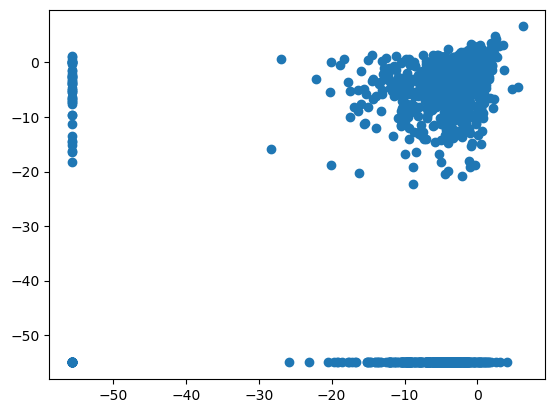

In [9]:


plt.scatter(samples_origin_std[:,0],samples_origin_std[:,1] )

In [10]:
# --- Identify columns with near-perfect pairwise tail dependence (chi close to 1)
# on the standardized scale, and remove the redundant ones from samples_origin_std ---

chi_std = cf.pairwise_chi_from_data(samples_origin, p=0.98)
chi_threshold = 0.9

cols_std = data.columns
d_std = chi_std.shape[0]

near1_pairs = [
    (cols_std[i], cols_std[j], chi_std[i, j])
    for i in range(d_std) for j in range(i + 1, d_std)
    if chi_std[i, j] >= chi_threshold
]
print(f'Column pairs with chi >= {chi_threshold}:')
for a, b, v in near1_pairs:
    print(f'  {a}-{b}: chi = {v:.3f}')

# Currencies pegged to a common anchor (e.g. HKG & SAU both pegged to USD) end up
# mutually near-1, so group indices into connected components via union-find and
# keep only one representative column per component (the first one encountered).
parent = list(range(d_std))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[max(ra, rb)] = min(ra, rb)

for i in range(d_std):
    for j in range(i + 1, d_std):
        if chi_std[i, j] >= chi_threshold:
            union(i, j)

drop_idx = sorted({i for i in range(d_std) if find(i) != i})
keep_idx = [i for i in range(d_std) if i not in drop_idx]

print('Dropping columns (chi close to 1 with another column):', list(cols_std[drop_idx]))
print('Keeping columns:', list(cols_std[keep_idx]))

samples_origin_std = samples_origin_std[:, keep_idx]
std_columns = cols_std[keep_idx]

samples_origin_std.shape

Column pairs with chi >= 0.9:
  DNK-EUR: chi = 0.980
  HKG-SAU: chi = 0.931
  HKG-USA: chi = 0.931
  SAU-USA: chi = 0.990
Dropping columns (chi close to 1 with another column): ['EUR', 'SAU', 'USA']
Keeping columns: ['AUS', 'CAN', 'CHN', 'CZE', 'DNK', 'HKG', 'HUN', 'IND', 'ISR', 'JPN', 'MYS', 'NZL', 'NOR', 'POL', 'SGP', 'ZAF', 'KOR', 'SWE', 'CHE', 'TWN', 'THA', 'TUR']


(1289, 22)

In [11]:
# --- Threshold the standardized data at its own 0.97 quantile and extract the joint
# threshold-exceedance data (same construction as `samples` above, now on the
# standardized scale) ---

samples_fm = samples_origin_std

samples_fm.shape

(1289, 22)

In [12]:
seed = 1234
rng = np.random.default_rng(seed)
idx_fm = rng.permutation(len(samples_fm))

# NOTE: with only 888 exceedance rows total, a 0.99 split left just 9 rows for
# validation -- far too few to get a stable MMD estimate over 22 dimensions.
# The resulting validation loss was pure noise (bouncing ~2.7-7.6 with no
# trend), so early stopping locked onto an essentially untrained epoch. 0.8
# (matching Simulation_1S.ipynb) leaves ~178 validation rows instead.
split_fm = int(0.8 * len(samples_fm))
train_idx_fm, val_idx_fm = idx_fm[:split_fm], idx_fm[split_fm:]

train_samples_fm = samples_fm[train_idx_fm]
val_samples_fm = samples_fm[val_idx_fm]

In [13]:
int(train_samples_fm.shape[0])

1031

In [104]:
train_samples_fm

array([[-5.56661443e+01, -1.65108515e+01,  2.98963774e-01,
        -1.39835909e+00, -2.06701200e+00, -3.09354733e+00,
        -7.41399842e-01,  4.83976008e-01, -5.06349731e+00,
        -7.18224327e-01, -2.46400636e+00, -6.10981095e+00,
        -6.23147920e+01, -5.84306475e-01, -4.70161919e+00,
        -4.11041526e+01, -1.01801428e+01, -3.30898398e+00,
        -1.74250453e+00, -5.45403767e+00, -2.34732530e+00,
        -2.60086867e+00],
       [-1.66336571e+00, -1.97581715e-01, -2.26874023e+00,
        -2.95190256e+00, -3.75723513e+00, -7.34493915e-01,
        -3.44403745e+00, -5.38312605e-01, -2.40956961e+00,
        -9.25840880e-01,  4.69142226e-01, -3.37369738e+00,
        -2.18901634e+00, -2.02361092e+00, -1.18768673e-01,
        -7.93544050e-01, -6.67184491e-01, -2.87021073e+00,
        -2.63954521e+00, -4.24786322e-01, -9.57025403e-01,
        -3.88456781e+01],
       [-9.12412023e+00, -5.50199003e+01, -9.91208896e+00,
        -4.71171327e+00, -3.48627333e+00, -5.42686636e+00,
    

In [101]:
# --- Model & flow architecture (S representation, fixed/identity margins) ---
dim_fm = samples_fm.shape[1]
latent_size_fm = dim_fm - 1
embed_dim_fm = 3* latent_size_fm
base_s_fm = nf.distributions.DiagGaussian(latent_size_fm)
latent_size_factor_fm = 6
num_layers_fm = 10
torch.manual_seed(0)

b_fm = torch.Tensor([1 if i % 2 == 0 else 0 for i in range(latent_size_fm)])
flows_fm = []

for i in range(num_layers_fm):
    mask = b_fm if i % 2 == 0 else (1 - b_fm)
    s_net = nf.nets.MLP([latent_size_fm + embed_dim_fm, latent_size_factor_fm * latent_size_fm, latent_size_fm], init_zeros=True, output_fn='tanh')
    t_net = nf.nets.MLP([latent_size_fm + embed_dim_fm, latent_size_factor_fm * latent_size_fm, latent_size_fm], init_zeros=True, output_fn='tanh')
    flows_fm.append(ConditionalMaskedAffineFlow(mask, s_net, t_net))
    flows_fm.append(ActNormConditional(latent_size_fm))

flow_model_fm = ConditionalNormalizingFlow(
    d=dim_fm, embed_dim=embed_dim_fm, flows=flows_fm, base=base_s_fm
).to(device)

# Full-batch: GPU memory is not the constraint here (dense MMD kernel matrices
# over a batch this size are a few MB at most on a 46GB-free A6000) -- the
# training set itself only has 710 rows, so batch_size_fm = train_samples_fm.shape[0]
# gives every optimizer step the entire training set as the MMD "real" sample.
batch_size_fm = 400
epochs_fm = 500

# --- Exact-likelihood (MLE) training instead of MMD ---
# MMD-based training (Rounds 1-2) showed a robust, hyperparameter-resistant
# "shrinkage toward the middle" bias for pairwise chi (verified on a
# controlled synthetic benchmark with known ground-truth asymptotic chi:
# more samples/step, more steps, a bigger mmd_lambda, and even a per-face-
# stratified MMD kernel all failed to close the gap for high-chi pairs).
# With fix_margin=True, log_prob_S_mGPD_std is the closed-form S-representation
# density (no numerical integral needed), so exact MLE is cheap here and, once
# ConditionalNormalizingFlow.log_prob's flow-inversion order bug is fixed
# (see GPDFlow_S.py), recovers high-chi pairs far more faithfully in the same
# benchmark (see plan). marg_lambda stays 0 since margins are pre-standardized
# (fix_margin=True freezes sigma=1, gamma=0) rather than fit by the model.
model_fm = S_mGPD_NF(
    dim=dim_fm,
    flow=flow_model_fm,
    device=device,
    penalty_lambda=1e4,
    fix_margin=True,
    mse_quantile_lambda=0,
    marg_lambda=0,
    use_likelihood=False,
    mmd_lambda = 25,
    mmd_samples_per_face= 128,
    censor_c = 0,
    censor_tau = 0.1,
    mmd_indicator_alpha = 5,
    mmd_indicator_rho = 2
)


# fix_margin=True freezes data_transform.log_sigma / theta as plain zero tensors
# (sigma=1, gamma=0, i.e. the identity map), so only the flow and face weights are optimized.
optimizer_fm = torch.optim.Adam(
    [
        {'params': model_fm.flow_model.parameters(), 'lr': 1e-3},
        {'params': [model_fm.log_pi_raw], 'lr': 1e-3},
    ],
)
scheduler_fm = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fm, epochs_fm)

print('Sigma (fixed):', model_fm.get_sigma().detach().cpu().numpy())
print('Gamma (fixed):', model_fm.get_gamma().detach().cpu().numpy())

seed = 1234
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

train_data_fm = torch.tensor(np.asarray(train_samples_fm), dtype=torch.float32, device=device)
val_data_fm = torch.tensor(np.asarray(val_samples_fm), dtype=torch.float32, device=device)

train_loader_fm = DataLoader(train_data_fm, batch_size=batch_size_fm, shuffle=True, drop_last=False)
val_loader_fm = DataLoader(val_data_fm, batch_size=batch_size_fm, shuffle=False, drop_last=False)

# patience/min_delta widened vs. the original (10, 0.0): with the 0.99 split the
# validation set had only 9 rows, so its MMD estimate was pure noise (bouncing
# ~2.7-7.6 across epochs) and early stopping locked onto essentially the
# untrained model at epoch 7. With ~178 validation rows (see split_fm above)
# the estimate is much less noisy, but a larger patience and a small positive
# min_delta still guard against stopping on residual epoch-to-epoch noise.
patience_fm = 100
min_delta_fm = 1e-3
best_val_fm = float('inf')
best_state_fm = None
best_epoch_fm = 0
bad_epochs_fm = 0

train_loss_history_fm = []
val_loss_history_fm = []

torch.autograd.set_detect_anomaly(True)

# --- Stats tracking helpers ---
def init_epoch_stats():
    return {
        'nll': 0.0,
        'support_loss': 0.0,
        'support_loss_weighted': 0.0,
        'mse_quantile_loss': 0.0,
        'mse_quantile_loss_weighted': 0.0,
        'loss_marg': 0.0,
        'loss_marg_weighted': 0.0,
        'mmd_loss': 0.0,
        'mmd_loss_weighted': 0.0,
        'total_loss': 0.0,
        'count': 0,
    }

def update_epoch_stats(stats_dict, comps, bsz):
    for key in [
        'nll', 'support_loss', 'support_loss_weighted',
        'mse_quantile_loss', 'mse_quantile_loss_weighted',
        'loss_marg', 'loss_marg_weighted',
        'mmd_loss', 'mmd_loss_weighted',
        'total_loss',
    ]:
        stats_dict[key] += comps[key].item() * bsz
    stats_dict['count'] += bsz

def finalize_epoch_stats(stats_dict):
    if stats_dict['count'] == 0:
        return stats_dict
    return {k: (v if k == 'count' else v / stats_dict['count']) for k, v in stats_dict.items()}


for epoch in range(epochs_fm):
    model_fm.train()
    train_stats = init_epoch_stats()

    for x_data in train_loader_fm:
        comps = model_fm(x_data, return_components=True, x_data_quantile=train_data_fm)
        batch_loss = comps['total_loss']

        if torch.isnan(batch_loss) or torch.isinf(batch_loss):
            print(f'[Epoch {epoch}] NaN/Inf detected in TRAIN loss. Stopping.')
            bad_epochs_fm = patience_fm
            break

        optimizer_fm.zero_grad(set_to_none=True)
        batch_loss.backward()
        torch.nn.utils.clip_grad_norm_(model_fm.parameters(), max_norm=1)
        optimizer_fm.step()

        update_epoch_stats(train_stats, comps, x_data.shape[0])

    train_stats = finalize_epoch_stats(train_stats)
    train_epoch_loss = train_stats['total_loss'] if train_stats['count'] > 0 else float('inf')
    train_loss_history_fm.append(train_epoch_loss)

    model_fm.eval()
    val_stats = init_epoch_stats()

    with torch.no_grad():
        for x_val in val_loader_fm:
            comps = model_fm(x_val, return_components=True)
            val_loss = comps['total_loss']

            if torch.isnan(val_loss) or torch.isinf(val_loss):
                print(f'[Epoch {epoch}] NaN/Inf detected in VAL loss. Stopping.')
                bad_epochs_fm = patience_fm
                break

            update_epoch_stats(val_stats, comps, x_val.shape[0])

    val_stats = finalize_epoch_stats(val_stats)
    val_epoch_loss = val_stats['total_loss'] if val_stats['count'] > 0 else float('inf')
    val_loss_history_fm.append(val_epoch_loss)

    scheduler_fm.step()

    lr_now = scheduler_fm.get_last_lr()[0]
    print(
        f"Epoch {epoch+1:4d}/{epochs_fm} | "
        f"train={train_stats['total_loss']:.4f} | "
        f"val={val_stats['total_loss']:.4f} | "
        f"lr={lr_now:.3e}"
    )
    print(
        f"  TRAIN | nll={train_stats['nll']:.4f} | marg_w={train_stats['loss_marg_weighted']:.4f} | "
        f"supp_w={train_stats['support_loss_weighted']:.4f}"
    )
    print(
        f"  VALID | nll={val_stats['nll']:.4f} | marg_w={val_stats['loss_marg_weighted']:.4f} | "
        f"supp_w={val_stats['support_loss_weighted']:.4f}"
    )

    improved = (best_val_fm - val_epoch_loss) > min_delta_fm

    if improved:
        best_val_fm = val_epoch_loss
        best_epoch_fm = epoch + 1
        bad_epochs_fm = 0
        best_state_fm = {k: v.detach().cpu().clone() for k, v in model_fm.state_dict().items()}
    else:
        bad_epochs_fm += 1

    if bad_epochs_fm >= patience_fm:
        print(f'Early stopping at epoch {epoch + 1} (no val loss improvement for {patience_fm} epochs).')
        break

if best_state_fm is not None:
    model_fm.load_state_dict(best_state_fm)

print(f'Optimal epoch (best validation loss): {best_epoch_fm}')
print('Final Gamma (should be ~0, fixed):', model_fm.data_transform.get_gamma())
print('Final Sigma (should be ~1, fixed):', model_fm.data_transform.get_sigma())

Sigma (fixed): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Gamma (fixed): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Epoch    1/500 | train=18.0237 | val=7.5928 | lr=1.000e-03
  TRAIN | nll=0.0000 | marg_w=0.0000 | supp_w=0.0000
  VALID | nll=0.0000 | marg_w=0.0000 | supp_w=0.0000
Epoch    2/500 | train=5.0144 | val=0.8772 | lr=1.000e-03
  TRAIN | nll=0.0000 | marg_w=0.0000 | supp_w=0.0000
  VALID | nll=0.0000 | marg_w=0.0000 | supp_w=0.0000
Epoch    3/500 | train=0.7446 | val=0.3108 | lr=9.999e-04
  TRAIN | nll=0.0000 | marg_w=0.0000 | supp_w=0.0000
  VALID | nll=0.0000 | marg_w=0.0000 | supp_w=0.0000
Epoch    4/500 | train=0.8081 | val=0.4586 | lr=9.998e-04
  TRAIN | nll=0.0000 | marg_w=0.0000 | supp_w=0.0000
  VALID | nll=0.0000 | marg_w=0.0000 | supp_w=0.0000
Epoch    5/500 | train=0.5334 | val=0.4425 | lr=9.998e-04
  TRAIN | nll=0.0000 | marg_w=0.0000 | supp_w=0.0000
  VALID | nll=0.0000 | marg_w=0.0000 | supp_w=0.0000
Epoch    6/50

In [99]:
# --- Evaluate: pairwise chi comparison against the empirical estimate on samples_origin ---
# pairwise_chi_from_data is rank-based, hence invariant to the per-margin monotone
# g_std transform, so it is valid to compare directly against the raw-scale empirical chi.
chi_true_fm = cf.pairwise_chi_from_data(samples_origin[:, keep_idx], p=0.97)
model_fm.eval()
samples_obs_fm, samples_y_fm, samples_s_fm = model_fm.sample(50000)
samples_simu_fm = samples_obs_fm.cpu().detach()
chi_hat_fm = cf.pairwise_chi_from_data(samples_simu_fm, p=0.9)
print(cf.tde_chi(chi_hat_fm, chi_true_fm))

0.02252948931004757


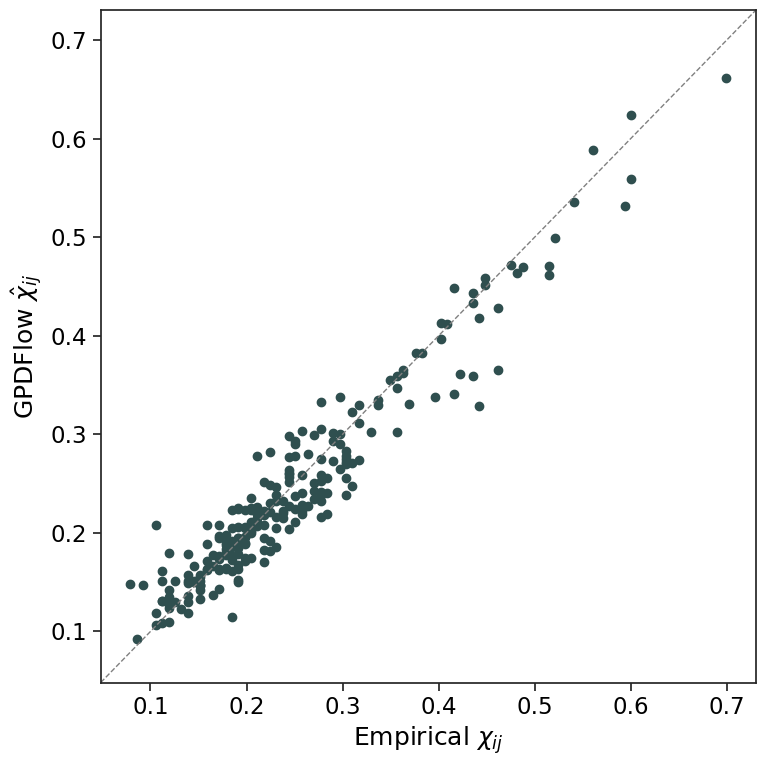

In [100]:
# Scatter plot of empirical vs. GPDFlow-estimated pairwise chi, over the upper
# triangular block (all i<j pairs)
idx = np.triu_indices(22, k=1)
chi_true_upper = chi_true_fm[idx]
chi_hat_upper = chi_hat_fm[idx]

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(chi_true_upper, chi_hat_upper, color='darkslategray')
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Empirical $\chi_{ij}$', color='black')
ax.set_ylabel(r'GPDFlow $\hat{\chi}_{ij}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
fig.tight_layout()
plt.show()